In [8]:
import heapq
import matplotlib.pyplot as plt
import networkx as nx

# 1. DATA STRUCTURE POPULATION

graph = {

    'Andheri Bhim Nagar': {
        'Andheri East': 2
    },

    'Andheri East': {
        'NH-48': 2,
        'Aarey Road': 3,
        'Service Road': 2
    },

    # Route 1
    'NH-48': {
        'Jogeshwari': 2
    },

    # Route 2
    'Aarey Road': {
        'Aarey Colony': 3
    },

    'Aarey Colony': {
        'Goregaon East': 3
    },

    # Route 3
    'Service Road': {
        'Jogeshwari Service Road': 2
    },

    'Jogeshwari': {
        'Goregaon East': 2
    },

    'Jogeshwari Service Road': {
        'Goregaon East': 4
    },

    'Goregaon East': {}
}

# Straight-line Heuristic Distance h(n)

heuristics = {

    'Andheri Bhim Nagar': 9,
    'Andheri East': 7,
    'NH-48': 5,
    'Aarey Road': 6,
    'Aarey Colony': 3,
    'Service Road': 6,
    'Jogeshwari': 2,
    'Jogeshwari Service Road': 3,
    'Goregaon East': 0
}

node_positions = {

    'Andheri Bhim Nagar': (2,8),
    'Andheri East': (2,7),

    'NH-48': (1,6),
    'Aarey Road': (3,6),
    'Service Road': (5,6),

    'Jogeshwari': (1,4),
    'Aarey Colony': (3,4),
    'Jogeshwari Service Road': (5,4),

    'Goregaon East': (3,1)
}

In [9]:
# 2. A* SEARCH ALGORITHM

def a_star_search(graph, heuristics, start, goal):

    priority_queue = [(heuristics[start], start, [start], 0)]

    visited = set()

    while priority_queue:

        f_score, current, path, g_score = heapq.heappop(priority_queue)

        if current in visited:
            continue

        visited.add(current)

        if current == goal:
            return path, g_score

        for neighbor, edge_weight in graph[current].items():

            if neighbor not in visited:

                next_g = g_score + edge_weight
                next_f = next_g + heuristics[neighbor]

                heapq.heappush(
                    priority_queue,
                    (next_f, neighbor, path + [neighbor], next_g)
                )

    return None, float('inf')

optimal_path, total_distance = a_star_search(
    graph,
    heuristics,
    'Andheri Bhim Nagar',
    'Goregaon East'
)

print(f"Optimal Path Discovered: {' -> '.join(optimal_path)}")
print(f"Total Road Distance: {total_distance} km\n")


Optimal Path Discovered: Andheri Bhim Nagar -> Andheri East -> NH-48 -> Jogeshwari -> Goregaon East
Total Road Distance: 8 km



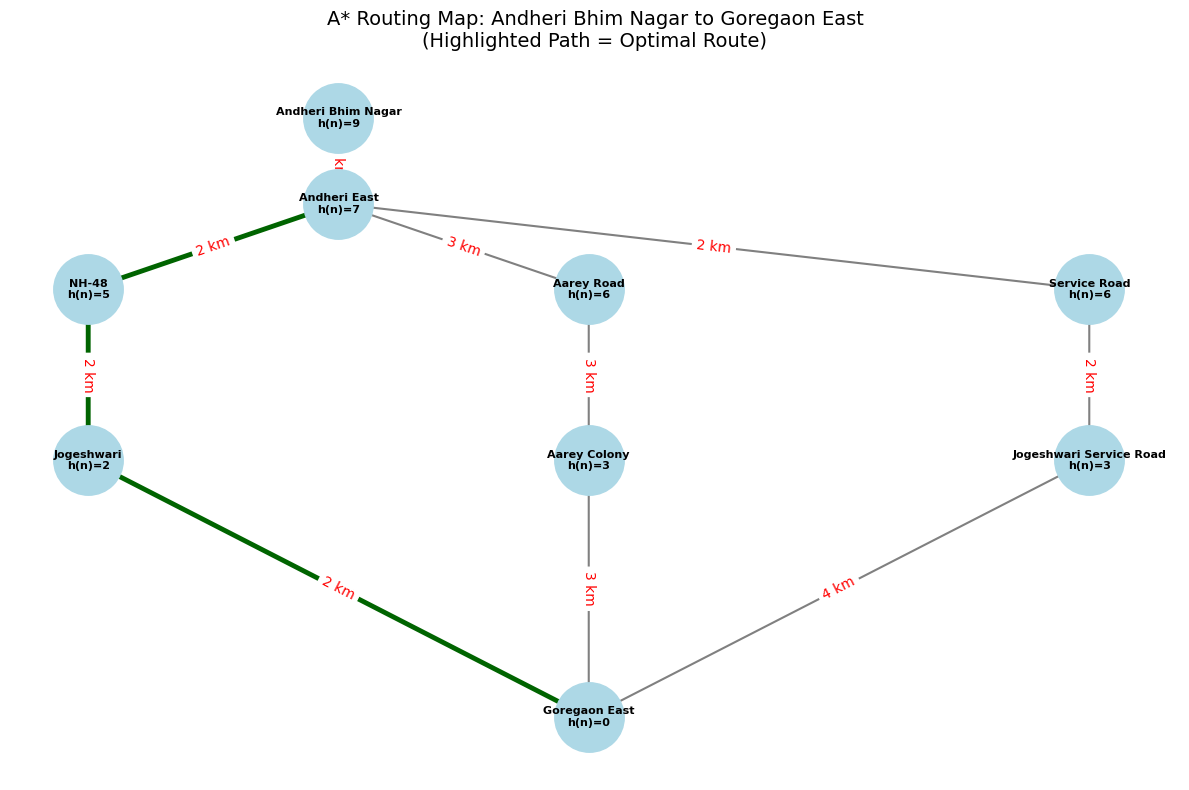

In [15]:
G = nx.DiGraph()

for node, neighbors in graph.items():
    for neighbor, weight in neighbors.items():
        G.add_edge(node, neighbor, weight=weight)

plt.figure(figsize=(12,8))

path_edges = list(zip(optimal_path, optimal_path[1:]))

normal_edges = [
    edge for edge in G.edges()
    if edge not in path_edges
]

nx.draw_networkx_nodes(
    G,
    node_positions,
    node_size=2500,
    node_color='lightblue'
)

nx.draw_networkx_edges(
    G,
    node_positions,
    edgelist=normal_edges,
    width=1.5,
    edge_color='gray',
    arrows=True
)

nx.draw_networkx_edges(
    G,
    node_positions,
    edgelist=path_edges,
    width=3.5,
    edge_color='darkgreen',
    arrows=True
)

node_labels = {
    node: f"{node}\nh(n)={heuristics[node]}"
    for node in G.nodes()
}

nx.draw_networkx_labels(
    G,
    node_positions,
    labels=node_labels,
    font_size=8,
    font_weight='bold'
)

edge_labels = nx.get_edge_attributes(G, 'weight')

formatted_edge_labels = {
    k: f"{v} km"
    for k, v in edge_labels.items()
}

nx.draw_networkx_edge_labels(
    G,
    node_positions,
    edge_labels=formatted_edge_labels,
    font_color='red'
)

plt.title(
    "A* Routing Map: Andheri Bhim Nagar to Goregaon East\n"
    "(Highlighted Path = Optimal Route)",
    fontsize=14
)

plt.axis('off')
plt.tight_layout()
plt.show()